In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set visualization style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [24]:
np.random.seed(42)
n_samples = 100

data = {
    'Variant_ID': [f"rs_{i}" for i in range(100, 100 + n_samples)],
    'Allele_Freq': np.random.uniform(0, 0.2, n_samples),
    'CADD_Score': np.random.uniform(0, 45, n_samples),
    'GERP_Score': np.random.uniform(-2, 7, n_samples),
    'Consequence': np.random.choice(['Missense', 'Nonsense', 'Synonymous', 'Frameshift'], n_samples)
}

df = pd.DataFrame(data)

# Randomized logic for 'Is_Dangerous' (Target)
def define_danger(row):
    score = 0
    if row['CADD_Score'] > 22: score += 2
    if row['Allele_Freq'] < 0.01: score += 2
    if row['Consequence'] in ['Nonsense', 'Frameshift']: score += 3
    # Shuffling the results with random noise to ensure it's not a perfect sequence
    noise = np.random.choice([-1, 0, 1], p=[0.1, 0.8, 0.1])
    return 1 if (score + noise) >= 3 else 0

df['Is_Dangerous'] = df.apply(define_danger, axis=1)
df = df.sample(frac=1).reset_index(drop=True) # Shuffle the rows completely

print("Randomized Dataset Created. Preview:")
df.head(10)

Randomized Dataset Created. Preview:


,Variant_ID,Allele_Freq,CADD_Score,GERP_Score,Consequence,Is_Dangerous
0,rs_103,0.119732,22.885681,6.086988,Nonsense,1
1,rs_168,0.014910,1.834881,1.235420,Missense,0
2,rs_181,0.124660,5.106308,1.041956,Missense,0
3,rs_142,0.006878,22.376183,6.233780,Frameshift,1
4,rs_141,0.099035,11.330203,6.585357,Nonsense,1
5,rs_136,0.060923,23.345578,0.526951,Missense,0
6,rs_133,0.189777,15.192683,2.432659,Missense,0
7,rs_150,0.193917,40.871965,0.650040,Synonymous,0
8,rs_106,0.011617,18.467232,-1.086756,Synonymous,0
9,rs_164,0.056187,4.063040,5.896358,Missense,0


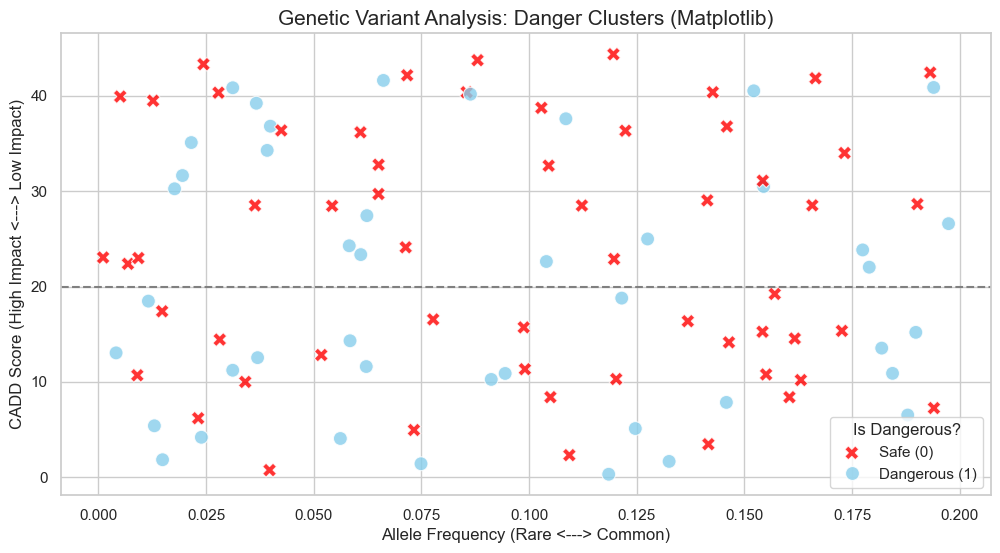

In [25]:
plt.figure(figsize=(12, 6))

# Scatter plot to see how Dangerous vs Safe variants are distributed
sns.scatterplot(data=df, x='Allele_Freq', y='CADD_Score', 
                hue='Is_Dangerous', style='Is_Dangerous', 
                palette={0: 'skyblue', 1: 'red'}, s=100, alpha=0.8)

plt.title('Genetic Variant Analysis: Danger Clusters (Matplotlib)', fontsize=15)
plt.xlabel('Allele Frequency (Rare <---> Common)')
plt.ylabel('CADD Score (High Impact <---> Low Impact)')
plt.axhline(y=20, color='gray', linestyle='--', label='Pathogenicity Threshold')
plt.legend(title="Is Dangerous?", labels=["Safe (0)", "Dangerous (1)"])
plt.show()

In [26]:
# Preprocessing: Convert text (Consequence) to numbers
df_ml = pd.get_dummies(df, columns=['Consequence'])

# X = Features, y = Target
X = df_ml.drop(['Variant_ID', 'Is_Dangerous'], axis=1)
y = df_ml['Is_Dangerous']

# Split data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Initialize and train
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

print("Model training complete on 80% of data.")


Model training complete on 80% of data.


Accuracy Score: 90.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.82      0.90        11

    accuracy                           0.90        20
   macro avg       0.91      0.91      0.90        20
weighted avg       0.92      0.90      0.90        20



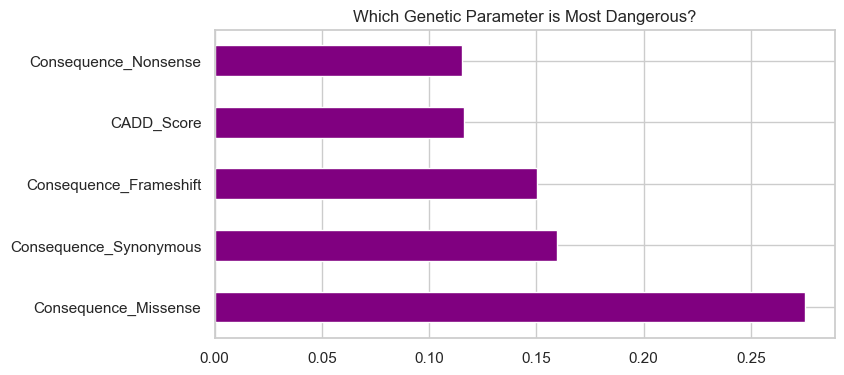

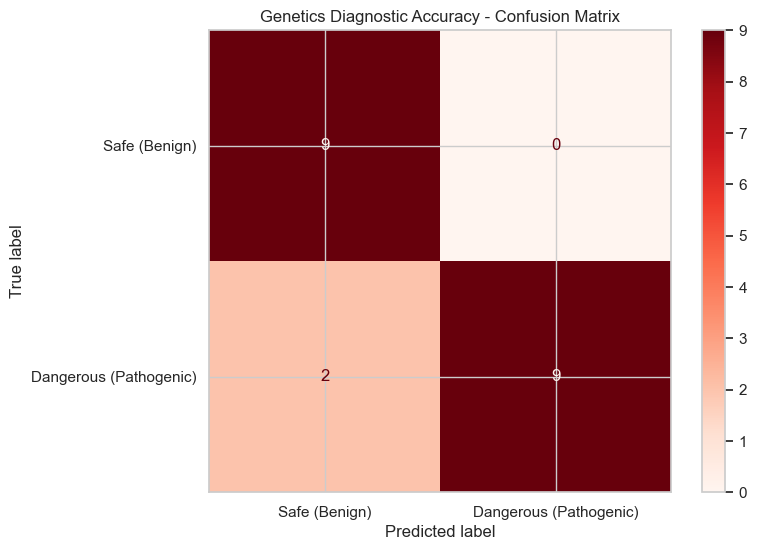

In [27]:
y_pred = clf.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Feature Importance
plt.figure(figsize=(8, 4))
feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh', color='purple')
plt.title('Which Genetic Parameter is Most Dangerous?')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=["Safe (Benign)", "Dangerous (Pathogenic)"],
    cmap='Reds', 
    ax=ax
)
plt.title('Genetics Diagnostic Accuracy - Confusion Matrix')
plt.show()

In [29]:
models= {
    'RandomForest' : RandomForestClassifier(),
    'Logistics Regression': LogisticRegression(),
    'SMV' : SVC(kernel = "linear"),
    "KNN" : KNeighborsClassifier(n_neighbors= 5),
    "Gradient Boosting" : GradientBoostingClassifier()
}

for name,model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {acc*100:.2f}% ")

RandomForest Accuracy: 85.00% 
Logistics Regression Accuracy: 90.00% 
SMV Accuracy: 90.00% 
KNN Accuracy: 35.00% 
Gradient Boosting Accuracy: 80.00% 
